# 📊 Challenge – Data Science (Júnior)

Bem-vindo ao **Challenge de Data Science** da BU de Dados e IA da GFT!

Este desafio faz parte do nosso processo de seleção para integrar a equipe responsável pelo **Agent Factory**, uma iniciativa estratégica com foco em soluções de inteligência baseadas em dados.

---

## 🎯 Objetivo

Seu objetivo neste desafio é construir um modelo simples de **machine learning** utilizando dados reais do ENEM, com o foco em **prever a nota da redação** de um candidato a partir de informações disponíveis no conjunto de dados.

---

## 🔍 O que você vai fazer

Você será responsável por seguir as principais etapas de um projeto de Ciência de Dados, de forma simples e organizada:

### 1. **Carregamento e exploração dos dados**

* Utilize o dataset que disponibilizamos neste link: 
* Faça a leitura, entenda as colunas disponíveis e identifique quais podem ser úteis para a tarefa.

### 2. **Análise exploratória dos dados (EDA)**

* Crie visualizações e tabelas para entender o comportamento das variáveis.
* Observe possíveis correlações com a nota da redação (`NU_NOTA_REDACAO`).
* Verifique a existência de valores ausentes ou inconsistentes.

### 3. **Construção do modelo**

Você pode escolher entre duas abordagens:

* **Regressão:** prever a nota exata da redação (de 0 a 1000).
* **Classificação:** prever a faixa de desempenho da redação (por exemplo):

  * **Baixa**: 0–400
  * **Média**: 401–800
  * **Alta**: 801–1000

> Lembre-se principalmente da etapa de Feature Engineering. O dataset tem algumas variáveis que, apesar de representadas por valores numéricos, são **categóricas**. Você deverá tratá-las corretamente para adicioná-las ao modelo, se julgar necessário.

### 4. **Avaliação do modelo**

* Para regressão: use métricas como **MAE**, **RMSE** ou **R²**.
* Para classificação: utilize **acurácia**, **precisão**, **recall**, **matriz de confusão**, etc.

### 5. **Conclusão**

* Destaque as variáveis que mais influenciaram na previsão.
* Comente o desempenho do modelo e possíveis melhorias.
* Aqui o que mais vale é sua explicação. Demonstre que entendeu todo o processo.

---

## 📁 Sobre os dados

Você estará trabalhando com um dataset real do ENEM 2019, extraído do site do INEP. Para este desafio, selecionamos apenas 10.000 registros e algumas colunas, com o objetivo de não tornar o dataset tão pesado para as análises. As colunas selecionadas foram: 

| Coluna            | Descrição                                                                 | Categorias / Valores Possíveis                                                       |
|-------------------|---------------------------------------------------------------------------|----------------------------------------------------------------------------------------|
| NU_ANO            | Ano de realização do exame.                                               | Ex: 2019                                                                  |
| NU_NOTA_CN        | Nota em Ciências da Natureza.                                             | Varia entre 0 e 1000                                                                  |
| NU_NOTA_CH        | Nota em Ciências Humanas.                                                 | Varia entre 0 e 1000                                                                  |
| NU_NOTA_LC        | Nota em Linguagens e Códigos.                                             | Varia entre 0 e 1000                                                                  |
| NU_NOTA_MT        | Nota em Matemática.                                                       | Varia entre 0 e 1000                                                                  |
| TP_ESCOLA         | Tipo de escola em que o participante concluiu ou está concluindo o EM.    | 1: Não respondeu <br>2: Pública<br>3: Privada<br>4: Exterior       |
| NU_NOTA_REDACAO   | Nota obtida na redação.                                                   | Varia entre 0 e 1000                                                                  |
| TP_ST_CONCLUSAO   | Situação de conclusão do Ensino Médio do participante.                    | 1: Já concluí<br>2: Estou cursando e vou concluir em 2019<br>3: Estou cursando e vou concluir após 2019 <br>4: Não concluí e não estou cursando o Ensino Médio|

---

## 📌 Entrega

Você deverá entregar um **notebook Jupyter (.ipynb)** com:

* As análises e visualizações realizadas
* O(s) modelo(s) criados
* Métricas utilizadas para avaliação
* Conclusões finais

> Organização, clareza nos comentários e boas práticas contam muitos pontos!

---

## 💡 Dicas

* Comece com uma amostra menor para explorar os dados mais rapidamente.
* Elimine colunas que não fazem sentido (como CPF, nome, código da prova, etc.).
* Tente diferentes algoritmos, mas priorize o entendimento sobre a complexidade.
* Comente cada etapa no seu notebook explicando o que está fazendo e porquê.
* **Não se preocupe *tanto* com o resultado final**. O objetivo maior do exercício é avaliar a linha de raciocínio e o pensamento crítico resolver o case.
* Você pode usar aplicações de IA Generativa. No entanto, todas as decisões serão questionadas. É importante entender o que está fazendo a todo momento.

---

## ✅ Critérios de Avaliação

* Clareza e organização do notebook
* Qualidade da análise exploratória
* Adequação do modelo e interpretação dos resultados
* Justificativa das decisões técnicas
* Comunicação das conclusões

---

Boa sorte, e divirta-se no processo!
Estamos ansiosos para ver como você vai transformar dados em conhecimento. 🚀

# 0. Imports

Faça aqui nesta seção todos os imports que você precisar. Já deixamos algumas sugestões prontas mas fique a vontade para usar quaisquer outras desejadas :)

In [70]:
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install scikit-learn
%pip install xgboost
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## 📁 1. Carregamento e limpeza dos dados

In [71]:
# remova os comentários para ler o arquivo do github
# carregando o dataset diretamente do github
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report


path = os.path.join('data', 'filtered-enem-2019.csv')
df = pd.read_csv(path)

### Limpeza e tratamento

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   NU_ANO           10000 non-null  int64  
 1   NU_NOTA_CN       10000 non-null  float64
 2   NU_NOTA_CH       10000 non-null  float64
 3   NU_NOTA_LC       10000 non-null  float64
 4   NU_NOTA_MT       10000 non-null  float64
 5   TP_ESCOLA        10000 non-null  int64  
 6   NU_NOTA_REDACAO  10000 non-null  int64  
 7   TP_ST_CONCLUSAO  10000 non-null  int64  
dtypes: float64(4), int64(4)
memory usage: 625.1 KB


In [73]:
missing_data = df.isnull().sum()
print(missing_data)

NU_ANO             0
NU_NOTA_CN         0
NU_NOTA_CH         0
NU_NOTA_LC         0
NU_NOTA_MT         0
TP_ESCOLA          0
NU_NOTA_REDACAO    0
TP_ST_CONCLUSAO    0
dtype: int64


Foi realizada a verificação de valores ausentes nas variáveis do conjunto de dados. Não foram identificados valores nulos nas colunas, portanto não foi necessário realizar tratamentos adicionais como remoção de dados.

### Visualizações iniciais

In [74]:
df['NU_NOTA_REDACAO'].describe()

count    10000.000000
mean       580.516000
std        179.652112
min          0.000000
25%        500.000000
50%        580.000000
75%        680.000000
max        980.000000
Name: NU_NOTA_REDACAO, dtype: float64

<Axes: >

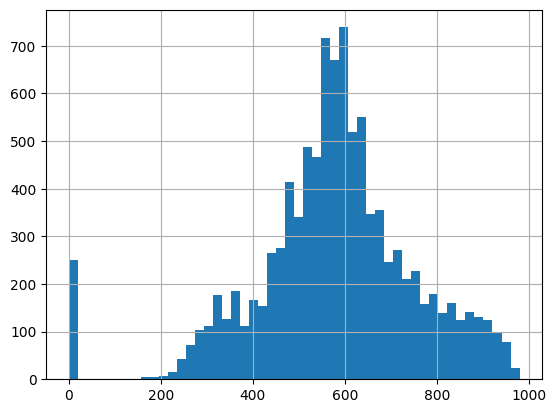

In [75]:
df['NU_NOTA_REDACAO'].hist(bins = 50)

A **distribuição** da variável `NU_NOTA_REDACAO` é aproxidamente simétrica. Há uma taxa de concentração maior entre os valores de 500 e 600 pontos, pode se notar também uma dispersão das notas nos intervalos de 700 a 1000, o que caracteriza uma tendencia mais **right-skewed**

Além disso, nota-se  **Outliers** com valores baixos, especialmente notas zeradas ou muito próximas de zero. 

## 🤖 2. Análise exploratória dos dados

In [76]:
df['NU_NOTA_REDACAO'].agg(['mean', 'median', 'std'])

mean      580.516000
median    580.000000
std       179.652112
Name: NU_NOTA_REDACAO, dtype: float64

De acordo com os resultados obtidos, a media e mediana apresentam valores próximos, o que ratifica com o histograma apresentado anteriormente. 

#### Analise da distribuição das Notas por  **Área de Conhecimento**

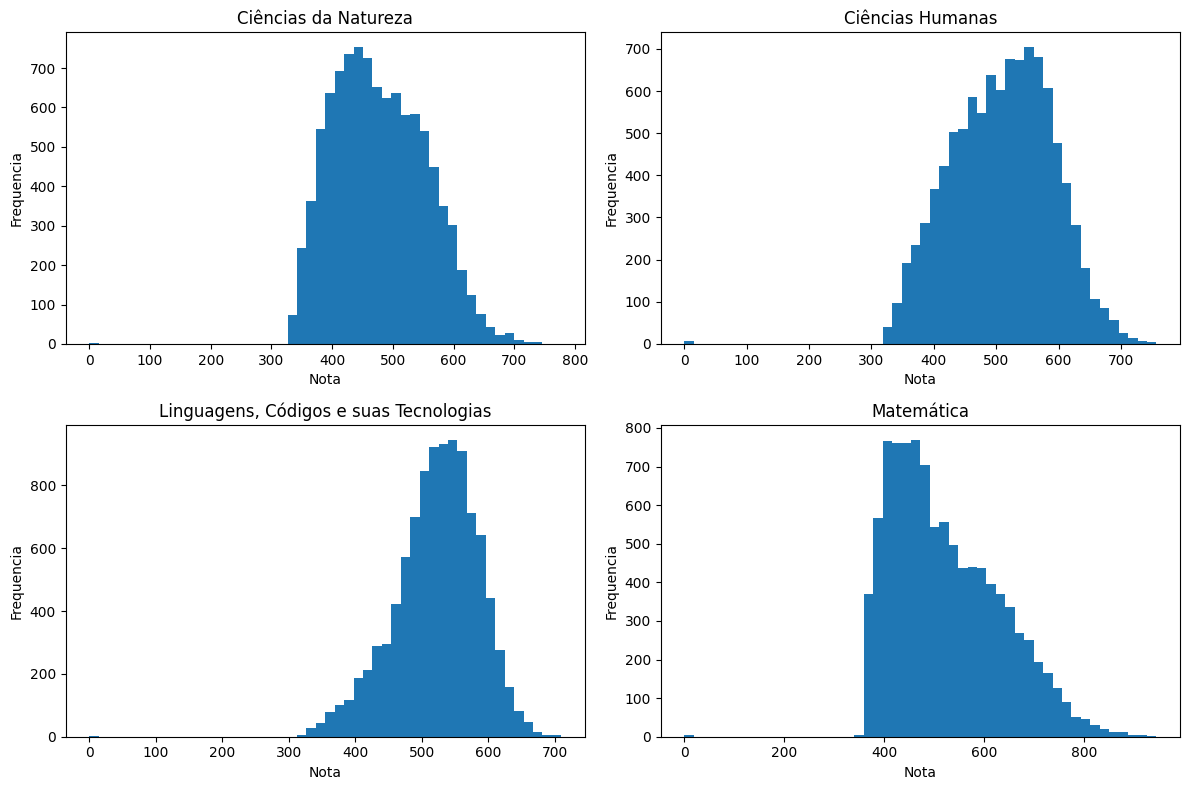

In [77]:
notas = {'NU_NOTA_CN': 'Ciências da Natureza',
    'NU_NOTA_CH': 'Ciências Humanas',
    'NU_NOTA_LC': 'Linguagens, Códigos e suas Tecnologias',
    'NU_NOTA_MT': 'Matemática'}

fig, axes = plt.subplots(2,2, figsize = (12,8))

for ax, (col,nome) in zip(axes.flatten(),notas.items()):
    ax.hist(df[col], bins = 50)
    ax.set_title(nome)
    ax.set_xlabel('Nota')
    ax.set_ylabel('Frequencia')

plt.tight_layout()
plt.show()

- #### *Ciências da Natureza*

In [78]:
df['NU_NOTA_CN'].agg(['mean', 'median'])

mean      478.29811
median    471.50000
Name: NU_NOTA_CN, dtype: float64

- #### *Ciências Humanas*

In [79]:
df['NU_NOTA_CH'].agg(['mean', 'median'])

mean      509.24935
median    513.55000
Name: NU_NOTA_CH, dtype: float64

- #### *Linguagens, Códigos e suas Tecnologias*

In [80]:
df['NU_NOTA_LC'].agg(['mean', 'median'])

mean      522.43657
median    528.05000
Name: NU_NOTA_LC, dtype: float64

- #### *Matemática*

In [81]:
df['NU_NOTA_MT'].agg(['mean', 'median'])

mean      523.58142
median    501.70000
Name: NU_NOTA_MT, dtype: float64

A analise gráfica e, da média e mediana das diferentes areas de conhecimento mostram diferentes padrões de assimetria. 

- A distribuição das notas de `Ciências da Natureza` apresentam uma tendencia simetrica a direita tendo a média superior a mediana. Isso indica poucos valores elevados influenciando a média.

- A distribuição das notas de `Ciências Humanas` apresentam uma leve simetria a esquerda tendo a mediana superior a médoa. Isso indica que a maioria dos alunos tem a nota acima da média.

- A distribuição das notas de `Linguagens` apresentam é proxima da simetria, indicando similaridade no desempenho dos candidatos.

- A distribuição das notas de `Matemática` apresentam forte assimetria a direita. A diferença significativa entre média e mediana indica a presença de poucos candidatos com notas elevadas.

### Análise da correlação das Notas por **Área de Conhecimento** x **Redação**

In [82]:
cols = ['NU_NOTA_CN','NU_NOTA_CH','NU_NOTA_LC','NU_NOTA_MT', 'NU_NOTA_REDACAO']

corr = df[cols].corr()
corr

,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
NU_NOTA_CN,1.000000,0.674521,0.646655,0.641393,0.493030
NU_NOTA_CH,0.674521,1.000000,0.753180,0.603931,0.532622
NU_NOTA_LC,0.646655,0.753180,1.000000,0.598464,0.542130
NU_NOTA_MT,0.641393,0.603931,0.598464,1.000000,0.492323
NU_NOTA_REDACAO,0.493030,0.532622,0.542130,0.492323,1.000000


In [83]:
corr_redacao = corr[['NU_NOTA_REDACAO']].drop('NU_NOTA_REDACAO')
corr_redacao

,NU_NOTA_REDACAO
NU_NOTA_CN,0.493030
NU_NOTA_CH,0.532622
NU_NOTA_LC,0.542130
NU_NOTA_MT,0.492323


<Axes: title={'center': 'Correlação entre as notas do ENEM e a Redação'}>

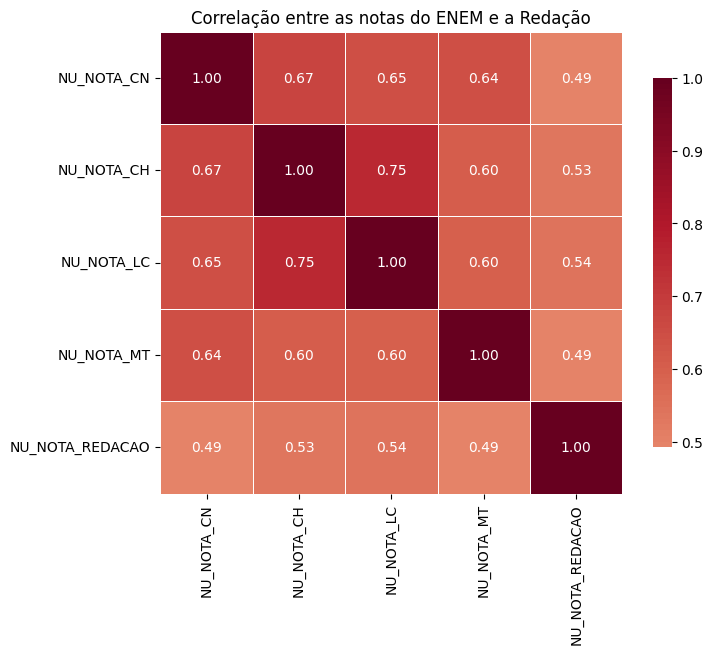

In [84]:
plt.figure(figsize=(8,6))
plt.title("Correlação entre as notas do ENEM e a Redação")

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

A analise da correlação entre as notas das areas de conhecimento com Redação indica relações moderadas em todas as disciplinas. A Maior correlação observada foi nas áreas de Linguagens(0,54), seguida por Ciências Humanas(0,53),Apenas Ciências da Natureza(0,49) e Matematica(0,49) apresentaram correlações inferiores.

Os resultados sugerem que as competencias em `Linguagens, Códigos e suas Tecnologias` exercem maior influencia no desempenho da redação.

### Análise bivariada entre a nota de **Linguagens** e a nota de **Redação**

Text(0, 0.5, 'Redação')

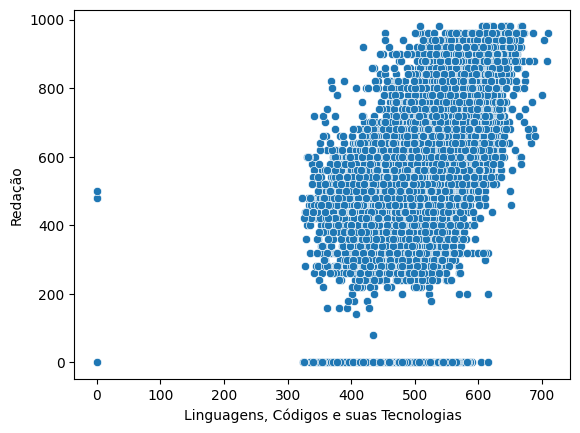

In [85]:
sns.scatterplot(data= df, x = 'NU_NOTA_LC',y = 'NU_NOTA_REDACAO')
plt.xlabel('Linguagens, Códigos e suas Tecnologias')
plt.ylabel('Redação')

Text(0, 0.5, 'Redação')

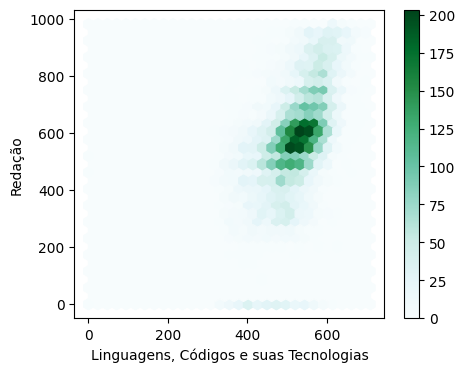

In [86]:
ax = df.plot.hexbin(x = 'NU_NOTA_LC',y = 'NU_NOTA_REDACAO', gridsize=30, sharex = False, figsize =(5,4))
plt.xlabel('Linguagens, Códigos e suas Tecnologias')
plt.ylabel('Redação')

Para analise bivariada foram escolhidos dois gráficas de dispersão. A area de `Linguagens, Códigos e suas Tecnologias` foi escolhida por ter apresentar **a maior correlação linear com a nota de redação** entre todas as áreas de conhecimento.

O primeiro gráfico exibe um scatter plot tradicional, no qual é possivel observar os comportamentos individuais dos estudantes e também a presença de outliers, como notas de redação igual a zero.
O segundo gráfico exibe um scatter plot hexbin onde evidencia com mais clareza a região de maior concentração de alunos, reduzindo a sobreposição de pontos e destacando o padrão geral de dados.

## 🧪 3. Construção do modelo (Treinamento e avaliação)

In [87]:
def classificar_redacao(nota):
    if nota <= 400:
        return "baixa"
    elif nota <= 800:
        return "media"
    else: 
        return "alta"

df['REDACAO_CLASSIF'] = df['NU_NOTA_REDACAO'].apply(classificar_redacao)

A nota da redação foi transformada em uma váriavel categórica `REDACAO_CLASSIF` com três classes: baixa, média e alta. O objetivo é facilitar a identificação de padrões de desempenho dos candidatos.

In [88]:
features = ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT',
       'TP_ESCOLA','TP_ST_CONCLUSAO']

X = df[features]
y = df['REDACAO_CLASSIF']

X = pd.get_dummies(X,columns=["TP_ESCOLA", "TP_ST_CONCLUSAO"],drop_first=True)

As variaveis explicativas(features) são as áreas de conhecimento junto com as caracteristicas educacionais do candidato. A variavel alvo corresponde a classificação de desempenho da redação.

As variáveis categóricas também foram transformadas em one-hot encoding. A opção drop_first=True foi utilizada para evitar problemas de multicolinearidade, mantendo uma categoria como referência.

In [89]:
X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=0.2,random_state=42, stratify= y)

In [90]:
rf_baseline = RandomForestClassifier(random_state=42)

rf_baseline.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [91]:

rf = RandomForestClassifier(n_estimators=200, max_depth= 10, random_state= 42)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

O conjunto de dados foi dividido em 80% para treino e 20% para teste. Foi utilizado o *stratify* para manter as proporções das classes. **O Random Forest Classifier** foi escolhido por ser mais eficiente em processar multiplas variáveis e capturar padrões mais complexos. 

## 🧠 4. Avaliação do modelo

- #### Modelo Baseline

In [92]:
y_pred_baseline = rf_baseline.predict(X_test)

accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
accuracy_baseline


0.7625

In [93]:
print(classification_report(y_test, y_pred_baseline))

              precision    recall  f1-score   support

        alta       0.61      0.31      0.41       205
       baixa       0.38      0.10      0.16       276
       media       0.79      0.94      0.86      1519

    accuracy                           0.76      2000
   macro avg       0.59      0.45      0.48      2000
weighted avg       0.71      0.76      0.72      2000



O modelo baseline, treinado com os parametros padrões do Random Forest apresentou acurácia de 0,76. Esse resultado serviu como referência para comparação com os modelos ajustados, indicando que ajustes de profundidade e balanceamento de classes foram necessários para melhorar a identificação das classes minoritárias, mesmo sem grandes ganhos na acurácia global.

- #### Modelo 1

In [94]:
y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
accuracy

0.774

O modelo apresentou 77% de acurácia. 


In [95]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

        alta       0.70      0.27      0.39       205
       baixa       0.38      0.02      0.03       276
       media       0.78      0.98      0.87      1519

    accuracy                           0.77      2000
   macro avg       0.62      0.42      0.43      2000
weighted avg       0.72      0.77      0.70      2000



A analise mais detalhada mostrou que há um recall de 98% para classe média enquanto as classes baixa e alta apresentam valores significativamente inferiores ( 2% e 27%),isso mostra que o modelo é incapaz de identificar adequadamente os extremos de desempenho.


- #### Modelo 2

In [96]:
rf_balanced = RandomForestClassifier(n_estimators=300, max_depth= 12,class_weight='balanced', random_state= 42)

rf_balanced.fit(X_train, y_train)

y_pred_balanced = rf_balanced.predict(X_test)
accuracy_balanced = accuracy_score(y_test, y_pred_balanced)
accuracy_balanced

0.6645

Para melhorar a identificação as classes minoritárias, nesse segundo modelo foi utilizado um novo parametro: `class_weight= 'balanced'`, que penaliza mais os erros cometidos nas classes menos frequentes.

Foi observado uma redução da acurácia global (66%) porém houve uma melhora significativa no recall das classes baixa e alta, mostrando que o modelo tem uma maior capacidade de identificar os extremos de desempenho.

In [97]:
print(classification_report(y_test,y_pred_balanced))

              precision    recall  f1-score   support

        alta       0.44      0.51      0.47       205
       baixa       0.33      0.60      0.43       276
       media       0.84      0.70      0.76      1519

    accuracy                           0.66      2000
   macro avg       0.54      0.60      0.55      2000
weighted avg       0.73      0.66      0.68      2000



- #### Comperação entre modelos

In [98]:
resultado = pd.DataFrame({
    'Modelo': [
        'Baseline (RF padrão)',
        'Random Forest ajustado',
        'Random Forest balanceado'
    ],
    'Acurácia': [
        0.7625,
        0.774,
        0.66
    ],
    'Recall Macro': [
        0.60,   
        0.42,   
        0.60    
    ]
})

resultado

,Modelo,Acurácia,Recall Macro
0,Baseline (RF padrão),0.7625,0.60
1,Random Forest ajustado,0.7740,0.42
2,Random Forest balanceado,0.6600,0.60


A comparação entre os modelos mostra que o Random Forest ajustado apresentou a maior acurácia, porém com desempenho limitado na identificação das classes menores, refletido no baixo recall macro. O modelo balanceado, apesar da redução na acurácia global, obteve melhor equilíbrio entre as classes, alcançando recall semelhante ao baseline.

## 🗣️ 5. Conclusão

O modelo de Machine Learning desenvolvido tem o objetivo de prever o desempenho na redacão do ENEM, a partir das nots das áreas de conhecimento. A análise exploratória indicou maior correlação da redação com a área de Linguagens, o que se refletiu nos resultados do modelo.

A escolha do Random Forest apresentou um bom desempenho no geral e o balanceamento de classes permitiu melhor identificar os extremos de desempenho.